# Hands-on 2 — Gaussian processes and the Wiener filter in NIFTy.re

**Course:** NIFTy in a day · **Session:** 11:45 – 12:45

In Hands-on 0 you wrote the Wiener filter by hand. Now we do it the NIFTy way and **check that both agree**.

**You will learn**
1. How NIFTy represents a field grid and its harmonic partner (`make_grid`, `mode_lengths`, `power_distributor`).
2. How to write a **Gaussian-process prior with a fixed power spectrum** as a standardized `jft.Model`.
3. How to write a **response** (mask) inside a model.
4. `jft.wiener_filter_posterior`: posterior mean, posterior samples, uncertainty maps.
5. What goes wrong when the assumed power spectrum is wrong (→ motivation for Hands-on 3).

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np

import nifty.re as jft
from nifty.re.correlated_field import hartley, make_grid

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 90
key = random.PRNGKey(7)

## 1. Grids: position space and harmonic space

`make_grid(shape, distances, "fourier")` returns a regular grid together with its **harmonic grid**:
* `grid.distances` — pixel size; `grid.total_volume` — size of the whole box.
* `grid.harmonic_grid.mode_lengths` — the distinct values of $|k|$ (the "shells").
* `grid.harmonic_grid.power_distributor` — an integer array with the shape of the field: for each Fourier pixel, the index of its $|k|$ shell. Indexing a 1-D spectrum with it "distributes" the spectrum onto the full Fourier grid.

total volume: 1.0  pixel size: (np.float64(0.0078125), np.float64(0.0078125))
number of |k| shells: (1621,)  first few: [0.         1.         1.41421356 2.         2.23606798 2.82842712]
power_distributor shape: (128, 128)


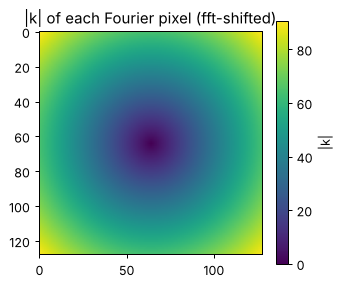

In [2]:
grid2 = make_grid((128, 128), distances=1 / 128, harmonic_type="fourier")
hg = grid2.harmonic_grid
print("total volume:", grid2.total_volume, " pixel size:", grid2.distances)
print("number of |k| shells:", hg.mode_lengths.shape, " first few:", hg.mode_lengths[:6])
print("power_distributor shape:", hg.power_distributor.shape)

plt.figure(figsize=(4, 3.5))
plt.imshow(jnp.fft.fftshift(hg.mode_lengths[hg.power_distributor]), cmap="viridis")
plt.colorbar(label="|k|"); plt.title("|k| of each Fourier pixel (fft-shifted)"); plt.show()

## 2. A Gaussian-process prior with a fixed spectrum, as a standardized model

Exactly §7 of Hands-on 0: $s = \frac{1}{V}\,\mathcal{H}\big[A(k)\,\xi\big]$, $\xi\sim\mathcal N(0,\mathbb 1)$ where $\mathcal H$ is the Hartley transform,
$V$ the total volume and $A(k)=\sqrt{P(k)}$ the **amplitude spectrum**. With this normalisation the pixel variance is
$\mathrm{Var}(s_x) = \frac{1}{V^2}\sum_k A(k)^2$ — we verify that numerically below.

empirical pixel variance : 0.12290314765740089
predicted Σ A(k)^2 / V^2 : 0.12320368624967847


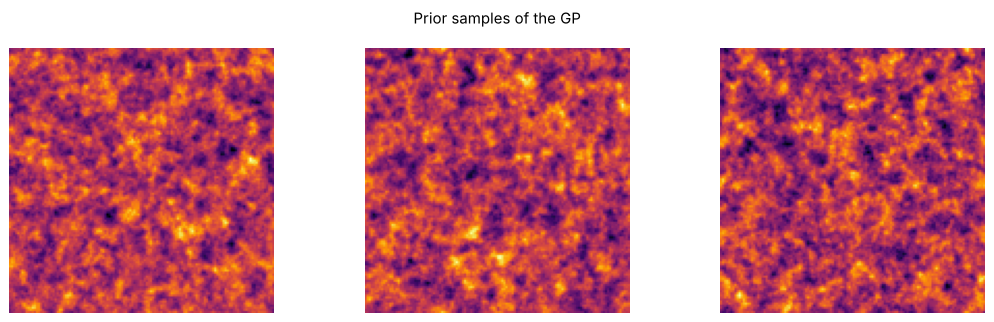

In [3]:
class FixedPowerGP(jft.Model):
    """s = (1/V) * Hartley(A(|k|) * xi), xi ~ N(0, 1)."""

    def __init__(self, shape, amplitude_fn, distances=None):
        shape = (shape,) if isinstance(shape, int) else tuple(shape)
        distances = tuple(1.0 / n for n in shape) if distances is None else distances
        self.grid = make_grid(shape, distances=distances, harmonic_type="fourier")
        self.amplitude_fn = amplitude_fn
        super().__init__(domain=jax.ShapeDtypeStruct(shape, jnp.float64))

    def amplitude_field(self):
        k = self.grid.harmonic_grid.mode_lengths
        return self.amplitude_fn(k)[self.grid.harmonic_grid.power_distributor]

    def __call__(self, xi):
        return hartley(self.amplitude_field() * xi) / self.grid.total_volume


amp_fn = lambda k: 0.02 / (1.0 + (k / 10.0) ** 2)        # A(k); P(k) = A(k)^2
gp = FixedPowerGP((128, 128), amp_fn)

key, sk = random.split(key)
draws = jax.vmap(gp)(random.normal(sk, (200, 128, 128)))
print("empirical pixel variance :", float(draws.var()))
print("predicted Σ A(k)^2 / V^2 :", float((gp.amplitude_field() ** 2).sum() / gp.grid.total_volume**2))

fig, axs = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, dr in zip(axs, draws[:3]):
    ax.imshow(dr.T, cmap="inferno", origin="lower"); ax.axis("off")
plt.suptitle("Prior samples of the GP"); plt.tight_layout(); plt.show()

Notice we passed `domain=` instead of `init=`: for a model whose input is just one standard-normal array, the domain
is all NIFTy needs. (`init=` is preferred when the model contains named prior components, as in Hands-on 1.)

## 3. Response and data

A checkerboard mask hides half the image. The response is a plain function inside a `jft.Model`; the model output
(the **signal response**) lives in data space, i.e. only the observed pixels.

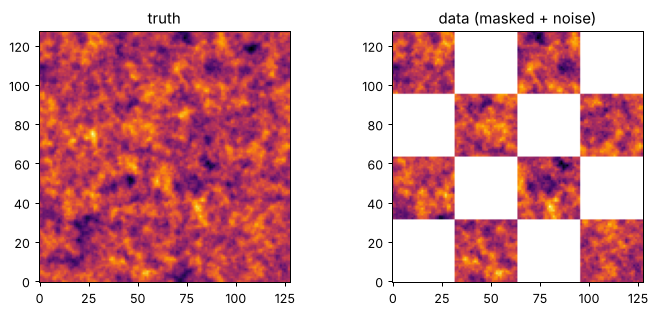

In [4]:
mask = np.ones((128, 128), bool)
for i in range(4):
    for j in range(4):
        if (i + j) % 2 == 0:
            mask[i * 32:(i + 1) * 32, j * 32:(j + 1) * 32] = False
mask = jnp.array(mask)


class MaskedGP(jft.Model):
    def __init__(self, gp, mask):
        self.gp, self.mask = gp, mask
        super().__init__(domain=gp.domain)

    def __call__(self, xi):
        return self.gp(xi)[self.mask]          # R s


signal_response = MaskedGP(gp, mask)
noise_std = 0.05
key, k_t, k_n = random.split(key, 3)
xi_truth = jft.random_like(k_t, signal_response.domain)
s_truth = gp(xi_truth)
data = signal_response(xi_truth) + noise_std * random.normal(k_n, signal_response.target.shape)

data_img = jnp.full((128, 128), jnp.nan).at[mask].set(data)
fig, axs = plt.subplots(1, 2, figsize=(8, 3.6))
axs[0].imshow(s_truth.T, cmap="inferno", origin="lower"); axs[0].set_title("truth")
axs[1].imshow(data_img.T, cmap="inferno", origin="lower"); axs[1].set_title("data (masked + noise)")
plt.tight_layout(); plt.show()

## 4. The Wiener filter with `jft.wiener_filter_posterior`

`jft.wiener_filter_posterior` solves $D^{-1}m=j$ with CG **in the standardized latent space** (the well-conditioned
system $\mathbb 1 + A^\dagger R^\dagger N^{-1} R A$ from Hands-on 0) and draws posterior samples.

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/usr/local/lib/python3.13/dist-packages/nifty/re/model.py:190: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


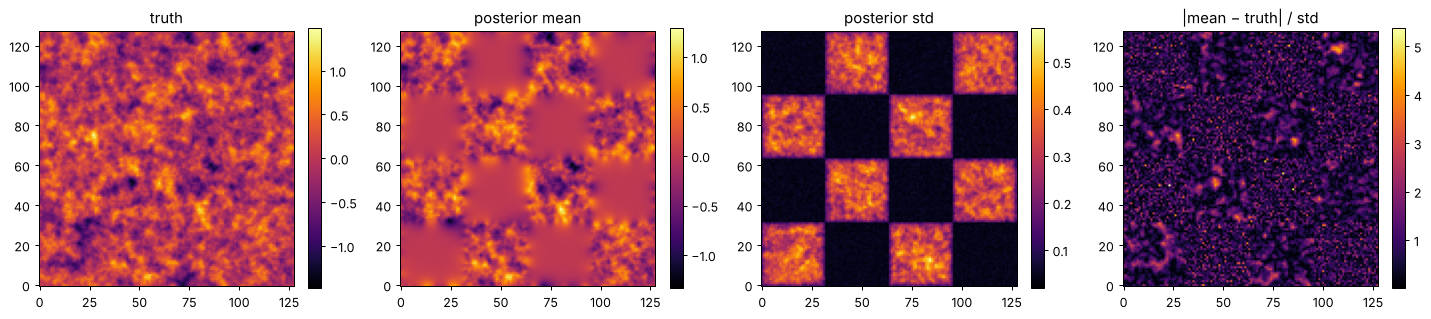

fraction of pixels with |error| < 1σ: 0.6739501953125 (≈0.68 if calibrated)


In [5]:
lh = jft.Gaussian(data, noise_cov_inv=lambda r: r / noise_std**2).amend(signal_response)

key, k_wf = random.split(key)
samples, info = jft.wiener_filter_posterior(
    lh,
    key=k_wf,
    n_samples=20,
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=1e-6 * jft.size(lh.domain) / 10, maxiter=500)),
)
post_mean, post_std = jft.mean_and_std(tuple(gp(s) for s in samples))

fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, (t, im) in zip(axs, [("truth", s_truth), ("posterior mean", post_mean),
                             ("posterior std", post_std), ("|mean − truth| / std", jnp.abs(post_mean - s_truth) / post_std)]):
    h = ax.imshow(im.T, cmap="inferno", origin="lower"); ax.set_title(t); plt.colorbar(h, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()
print("fraction of pixels with |error| < 1σ:", float((jnp.abs(post_mean - s_truth) < post_std).mean()), "(≈0.68 if calibrated)")

The std map is the checkerboard: small where we have data, large in the gaps, and largest in the **middle** of the
gaps (farthest from any observation). The last panel is a **calibration check** — about 68% of pixels should be within 1σ.

## 5. Cross-check against the hand-written Wiener filter

Same model, solved with the 10-line CG from Hands-on 0 in latent coordinates. The two posterior means must agree.

In [6]:
def cg(apply_A, b, tol=1e-10, maxiter=2000):
    x = jnp.zeros_like(b); r = b - apply_A(x); p = r; rs = jnp.vdot(r, r)
    for it in range(maxiter):
        Ap = apply_A(p); alpha = rs / jnp.vdot(p, Ap)
        x = x + alpha * p; r = r - alpha * Ap; rs_new = jnp.vdot(r, r)
        if jnp.sqrt(rs_new) < tol:
            break
        p = r + rs_new / rs * p; rs = rs_new
    return x, it + 1

R = jax.jit(signal_response)                       # xi -> R A xi
_, vjp_fn = jax.vjp(signal_response, xi_truth)     # adjoint via autodiff (linear model: exact)
RT = jax.jit(lambda v: vjp_fn(v)[0])

apply_Dinv = jax.jit(lambda v: v + RT(R(v)) / noise_std**2)
j = RT(data) / noise_std**2
m_xi_hand, its = cg(apply_Dinv, j)
print("hand CG iterations:", its)
print("max |m_hand − m_nifty| =", float(jnp.abs(gp(m_xi_hand) - gp(samples.pos)).max()))

hand CG iterations: 498
max |m_hand − m_nifty| = 0.0003424652580246712


Two NIFTy lessons hide in that cell:
* **Adjoints come for free** from JAX autodiff (`jax.vjp`) — in `nifty.re` you never write $R^\dagger$ by hand. (In `nifty.cl` you do: every `LinearOperator` implements `apply(x, mode)` for both directions.)
* The posterior **mean** of the latent $\xi$ maps to the posterior mean of $s$ only because the model is **linear**. For non-linear models you must average $s(\xi_i)$ over samples — always do that.

## 6. What if the assumed power spectrum is wrong?

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


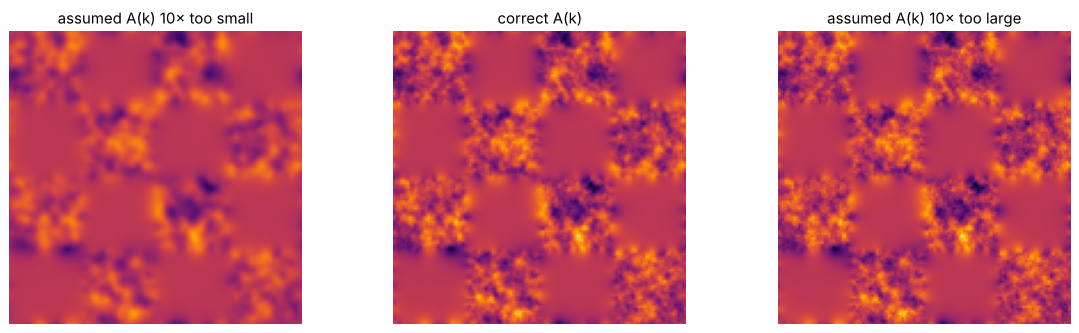

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (fac, title) in zip(axs, [(0.1, "assumed A(k) 10× too small"), (1.0, "correct A(k)"), (10.0, "assumed A(k) 10× too large")]):
    gp_wrong = FixedPowerGP((128, 128), lambda k, f=fac: f * amp_fn(k))
    lh_w = jft.Gaussian(data, noise_cov_inv=lambda r: r / noise_std**2).amend(MaskedGP(gp_wrong, mask))
    smp_w, _ = jft.wiener_filter_posterior(lh_w, key=random.PRNGKey(0), n_samples=0,
                                           draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(maxiter=500)))
    ax.imshow(gp_wrong(smp_w.pos).T, cmap="inferno", origin="lower", vmin=float(s_truth.min()), vmax=float(s_truth.max()))
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

* **Too small:** the prior says "the field barely varies" → reconstruction is shrunk towards 0, gaps are flat.
* **Too large:** the prior trusts every wiggle of the noise → over-fitting, and in the gaps the variance would be overestimated.

In reality we rarely know $P(k)$. NIFTy's answer is to **infer it jointly** — the correlated field model of Hands-on 3.

## ✏️ Exercises

**E2.1** Replace the checkerboard by a random mask observing only 10% of the pixels. How does the std map change?

**E2.2** Make the noise **heteroscedastic**: `noise_std` growing linearly from 0.01 (left) to 0.3 (right).
Pass `noise_cov_inv=lambda r: r / sig_map**2` where `sig_map` is the per-datum std. Where is the reconstruction best?

**E2.3** Turn the problem into **deconvolution**: response = Gaussian blur (use FFT multiplication, as in Hands-on 0 §5) followed by the mask.
You only need to change `MaskedGP.__call__` — the adjoint comes from JAX automatically.

**E2.4** Use `jft.wiener_filter_posterior(..., signal_space=False, noise_covariance=...)` (data-space formulation). When is it cheaper?
*(Hint: compare number of data points with number of pixels.)*

In [8]:
# Your work here

---
## Solutions

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


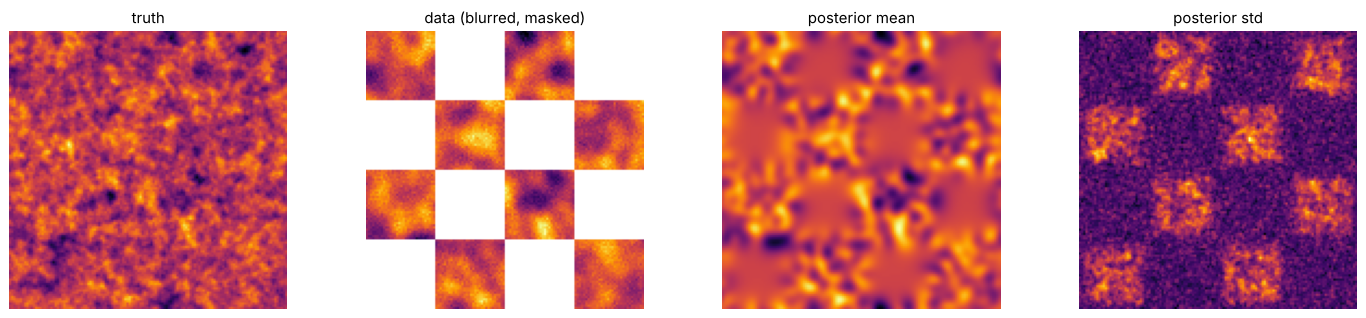

In [9]:
# E2.3 — deconvolution + mask
kx = jnp.fft.fftfreq(128) * 128
kk = jnp.sqrt(kx[:, None] ** 2 + kx[None, :] ** 2)
beam = jnp.exp(-0.5 * (kk / 8.0) ** 2)            # Gaussian beam in Fourier space

class BlurMaskGP(jft.Model):
    def __init__(self, gp, mask):
        self.gp, self.mask = gp, mask
        super().__init__(domain=gp.domain)

    def __call__(self, xi):
        blurred = jnp.fft.ifft2(beam * jnp.fft.fft2(self.gp(xi))).real
        return blurred[self.mask]

sr_blur = BlurMaskGP(gp, mask)
data_blur = sr_blur(xi_truth) + noise_std * random.normal(random.PRNGKey(11), sr_blur.target.shape)
lh_b = jft.Gaussian(data_blur, noise_cov_inv=lambda r: r / noise_std**2).amend(sr_blur)
smp_b, _ = jft.wiener_filter_posterior(lh_b, key=random.PRNGKey(12), n_samples=10,
                                       draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(maxiter=500)))
mb, sb = jft.mean_and_std(tuple(gp(s) for s in smp_b))
fig, axs = plt.subplots(1, 4, figsize=(16, 3.6))
for ax, (t, im) in zip(axs, [("truth", s_truth), ("data (blurred, masked)", jnp.full((128, 128), jnp.nan).at[mask].set(data_blur)),
                             ("posterior mean", mb), ("posterior std", sb)]):
    ax.imshow(im.T, cmap="inferno", origin="lower"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


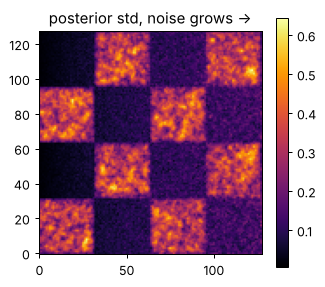

In [10]:
# E2.2 — heteroscedastic noise
xs = jnp.broadcast_to(jnp.linspace(0, 1, 128)[:, None], (128, 128))
sig_map = (0.01 + 0.29 * xs)[mask]
data_h = signal_response(xi_truth) + sig_map * random.normal(random.PRNGKey(13), sig_map.shape)
lh_h = jft.Gaussian(data_h, noise_cov_inv=lambda r: r / sig_map**2).amend(signal_response)
smp_h, _ = jft.wiener_filter_posterior(lh_h, key=random.PRNGKey(14), n_samples=10,
                                       draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(maxiter=500)))
_, sh = jft.mean_and_std(tuple(gp(s) for s in smp_h))
plt.figure(figsize=(4, 3.6)); plt.imshow(sh.T, cmap="inferno", origin="lower"); plt.title("posterior std, noise grows →")
plt.colorbar(); plt.show()